1372, 4, 2
[id:0, input:{[0.76900389 0.83964273 0.10678269 0.73662766]}, Class: 0]
[id:1, input:{[0.83565902 0.82098209 0.12180412 0.64432563]}, Class: 0]
[id:2, input:{[0.78662859 0.41664827 0.31060805 0.78695091]}, Class: 0]
[id:3, input:{[0.75710505 0.87169921 0.05492063 0.45043964]}, Class: 0]
[id:4, input:{[0.53157807 0.34866247 0.42466237 0.6873619 ]}, Class: 0]
[id:5, input:{[0.82285875 0.87727458 0.05710039 0.48971149]}, Class: 0]
[id:6, input:{[0.76681162 0.62810808 0.2591156  0.82857416]}, Class: 0]
[id:7, input:{[0.65871247 0.26054923 0.59231482 0.72251834]}, Class: 0]
[id:8, input:{[0.73883132 0.73085573 0.19525922 0.72157724]}, Class: 0]
[id:9, input:{[0.61857373 0.85876736 0.12985116 0.71040763]}, Class: 0]
[id:10, input:{[0.59615343 0.84382612 0.13236263 0.70394082]}, Class: 0]
[id:11, input:{[0.79556354 0.41409258 0.33087212 0.85573438]}, Class: 0]
[id:12, input:{[0.64480165 0.80208945 0.23434812 0.49441247]}, Class: 0]
[id:13, input:{[0.39412558 0.92109921 0.3374028  0

(Pittsburgh Solution) Variables: [(MichiganSolution) Variables: [11 1 4 0 ], Rule weight: 0.9217, Class label:  1], Objectives: [0.0 0.0 ], Attributes: {Number of classifier patterns: 330, Number of wins: 354, } (MichiganSolution) Variables: [2 1 11 0 ], Rule weight: 0.3415, Class label:  0], Objectives: [0.0 0.0 ], Attributes: {Number of classifier patterns: 66, Number of wins: 73, } (MichiganSolution) Variables: [4 12 6 4 ], Rule weight: 0.8652, Class label:  1], Objectives: [0.0 0.0 ], Attributes: {Number of classifier patterns: 237, Number of wins: 242, } (MichiganSolution) Variables: [6 12 0 0 ], Rule weight: 0.9899, Class label:  1], Objectives: [0.0 0.0 ], Attributes: {Number of classifier patterns: 23, Number of wins: 23, } (MichiganSolution) Variables: [0 0 0 14 ], Rule weight: 0.1913, Class label:  0], Objectives: [0.0 0.0 ], Attributes: {Number of classifier patterns: 42, Number of wins: 42, } (MichiganSolution) Variables: [3 1 0 5 ], Rule weight: 0.9472, Class label:  1], O

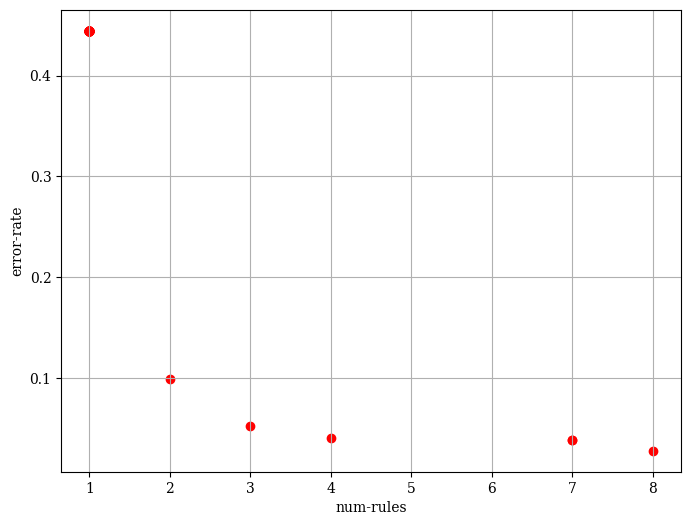

In [6]:
from pathlib import Path
import pandas as pd

from mofgbmlpy.data.input import Input
from sklearn.model_selection import KFold
from mofgbmlpy.fuzzy.knowledge.factory.homo_triangle_knowledge_factory_2_3_4_5 import \
    HomoTriangleKnowledgeFactory_2_3_4_5
from mofgbmlpy.main.nsgaii.mofgbml_nsgaii_main import MoFGBMLNSGAIIMain
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 

  
runner = MoFGBMLNSGAIIMain(HomoTriangleKnowledgeFactory_2_3_4_5)
import os
os.chdir("C:/Users/Ayato Tomofuji/Documents/Mof/MoFGBMLPy/examples")
args = [
    "--algorithm-id", "1",
    "--experiment-id", "2",
    "--data-name", "yeast",
    "--train-file", "dataset/yeast/a0_0_yeast-10tra.dat",
    "--test-file", "dataset/yeast/a0_0_yeast-10tra.dat",
    "--terminate-evaluation", "30000",
    "--objectives", "num-rules", "error-rate",
    # "--crossover-type", "pittsburgh-crossover",
    # "--antecedent-factory", "all-combination-antecedent-factory",
    "--no-output-files",
    "--verbose",
]
import os
os.chdir("C:/Users/Ayato Tomofuji/Documents/Mof/MoFGBMLPy/")

ozone_path = "dataset/banknote/banknote_all.dat"

X = Input().input_data_set(ozone_path, is_multi_label=False)

print(X)
#runner.main(sys.argv[1:])
kf = KFold(n_splits=10, shuffle=False, random_state=None)
results = runner.main(args, train=X, test=X)
min_length = results.opt.get("X")[0, 0].get_var(0).get_rule().get_length()
max_length = min_length
for sol in results.opt.get("X")[:, 0]:
    for var in sol.get_vars():
        length = var.get_rule().get_length()
        if length < min_length:
            min_length = length
        elif length > max_length:
            max_length = length
print(min_length, max_length)
i = 1
for var in results.opt.get("X")[0, 0].get_vars():
    print(f"{i}:\t{var.get_rule().get_linguistic_representation()}")
    i += 1
plot = runner.get_pareto_front_plot(results.opt)
plot.show()
# plot.ax.set_ylim([0,1])
plot.ax.grid(visible=True)
results.opt.get('X')[1, 0]

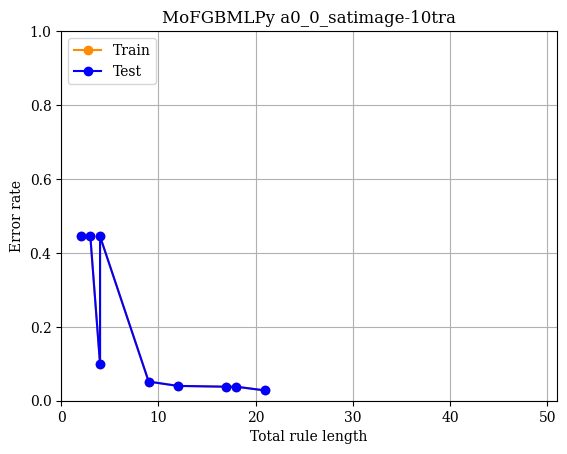

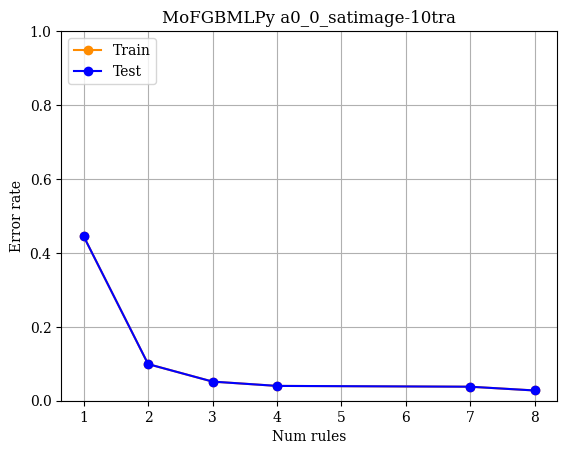


識別器 1 のルール:
  ルール 1: IF	     x0 IS very_high_5 AND x1 IS very_high_5 AND x2 IS medium_3 AND x3 IS medium_3 THEN Class is  0 with RW: 1.0000 RW: 1.0000

識別器 2 のルール:
  ルール 1: IF	    x0 IS low_5 AND x1 IS low_2 AND x2 IS medium_3 THEN Class is  1 with RW: 0.9217 RW: 0.9217
  ルール 2: IF	    x0 IS high_2 AND x1 IS low_2 AND x2 IS low_5 THEN Class is  0 with RW: 0.3415 RW: 0.3415
  ルール 3: IF	     x0 IS medium_3 AND x1 IS medium_5 AND x2 IS low_4 AND x3 IS medium_3 THEN Class is  1 with RW: 0.8652 RW: 0.8652
  ルール 4: IF	   x0 IS low_4 AND x1 IS medium_5 THEN Class is  1 with RW: 0.9899 RW: 0.9899
  ルール 5: IF	  x3 IS very_high_5 THEN Class is  0 with RW: 0.1913 RW: 0.1913
  ルール 6: IF	    x0 IS low_3 AND x1 IS low_2 AND x3 IS high_3 THEN Class is  1 with RW: 0.9472 RW: 0.9472
  ルール 7: IF	   x0 IS medium_3 AND x3 IS medium_5 THEN Class is  0 with RW: 0.0492 RW: 0.0492
  ルール 8: IF	    x0 IS high_2 AND x2 IS low_5 AND x3 IS medium_3 THEN Class is  0 with RW: 0.4572 RW: 0.4572

識別器 3 のルール:
  ルール 1:

In [7]:
runner.plot_line_interpretability_error_rate_tradeoff(results.opt.get('X')[:, 0],
                                                      title="MoFGBMLPy a0_0_satimage-10tra", xlim=[0, 51])
runner.plot_line_interpretability_error_rate_tradeoff(results.opt.get('X')[:, 0],
                                                      title="MoFGBMLPy a0_0_satimage-10tra", x_key='num_rules')

for idx, sol in enumerate(results.opt.get("X")[:, 0]):
    print(f"\n識別器 {idx + 1} のルール:")
    # 各識別器のルールを取得し表示
    for rule_idx, var in enumerate(sol.get_vars(), start=1):
        print(f"  ルール {rule_idx}: {var.get_rule().get_linguistic_representation()}")
